In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", None)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
archivos = files.upload()

Saving dataset_afluencia_real_preparado.csv to dataset_afluencia_real_preparado.csv


In [3]:
nombre_archivo = next(iter(archivos))

df = pd.read_csv(
    nombre_archivo,
    encoding="utf-8-sig"
)

df["Fecha"] = pd.to_datetime(
    df["Fecha"],
    errors="coerce"
)

df = (
    df.sort_values(["Fecha", "Hora"])
    .reset_index(drop=True)
)

print("Archivo:", nombre_archivo)
print("Dimensiones:", df.shape)
print("Periodo:", df["Fecha"].min(), "-", df["Fecha"].max())
print("Valores nulos:", df.isnull().sum().sum())

df.head()

Archivo: dataset_afluencia_real_preparado.csv
Dimensiones: (1248, 11)
Periodo: 2026-04-10 00:00:00 - 2026-09-28 00:00:00
Valores nulos: 0


,Fecha,Hora,Sede,CantidadIngresos,DiaSemana,Mes,DiaMes,SemanaAnio,EsLunes,EsViernes,Turno
0,2026-04-10,8,Central,0,4,4,10,15,0,1,Mañana
1,2026-04-10,9,Central,0,4,4,10,15,0,1,Mañana
2,2026-04-10,10,Central,0,4,4,10,15,0,1,Mañana
3,2026-04-10,11,Central,0,4,4,10,15,0,1,Mañana
4,2026-04-10,12,Central,2,4,4,10,15,0,1,Mañana


In [4]:
fechas_unicas = np.array(
    sorted(df["Fecha"].dt.normalize().unique())
)

cantidad_fechas = len(fechas_unicas)
punto_corte = int(cantidad_fechas * 0.80)

fechas_entrenamiento = fechas_unicas[:punto_corte]
fechas_prueba = fechas_unicas[punto_corte:]

df_train = df[
    df["Fecha"].dt.normalize().isin(fechas_entrenamiento)
].copy()

df_test = df[
    df["Fecha"].dt.normalize().isin(fechas_prueba)
].copy()

print("Fechas totales:", cantidad_fechas)
print("Fechas de entrenamiento:", len(fechas_entrenamiento))
print("Fechas de prueba:", len(fechas_prueba))

print("\nEntrenamiento:")
print(df_train["Fecha"].min(), "-", df_train["Fecha"].max())
print("Filas:", len(df_train))

print("\nPrueba:")
print(df_test["Fecha"].min(), "-", df_test["Fecha"].max())
print("Filas:", len(df_test))

assert df_train["Fecha"].max() < df_test["Fecha"].min(), \
    "Existe cruce temporal entre entrenamiento y prueba"

print("\nDivisión temporal correcta")

Fechas totales: 96
Fechas de entrenamiento: 76
Fechas de prueba: 20

Entrenamiento:
2026-04-10 00:00:00 - 2026-08-28 00:00:00
Filas: 988

Prueba:
2026-08-31 00:00:00 - 2026-09-28 00:00:00
Filas: 260

División temporal correcta


In [5]:
limite_bajo = int(
    df_train["CantidadIngresos"].quantile(0.33)
)

limite_alto = int(
    df_train["CantidadIngresos"].quantile(0.66)
)

print("Límite Bajo:", limite_bajo)
print("Límite Alto:", limite_alto)

def asignar_nivel(cantidad):
    if cantidad <= limite_bajo:
        return "Bajo"
    elif cantidad <= limite_alto:
        return "Medio"
    else:
        return "Alto"

df_train["NivelAfluencia"] = (
    df_train["CantidadIngresos"].apply(asignar_nivel)
)

df_test["NivelAfluencia"] = (
    df_test["CantidadIngresos"].apply(asignar_nivel)
)

print("\nDistribución de entrenamiento:")
print(df_train["NivelAfluencia"].value_counts())

print("\nDistribución de prueba:")
print(df_test["NivelAfluencia"].value_counts())

Límite Bajo: 4
Límite Alto: 34

Distribución de entrenamiento:
NivelAfluencia
Bajo     339
Alto     329
Medio    320
Name: count, dtype: int64

Distribución de prueba:
NivelAfluencia
Medio    131
Alto      80
Bajo      49
Name: count, dtype: int64


In [6]:
variables = [
    "Hora",
    "DiaSemana",
    "Mes",
    "DiaMes",
    "SemanaAnio",
    "EsLunes",
    "EsViernes"
]

X_train = df_train[variables].copy()
X_test = df_test[variables].copy()

y_train = df_train["NivelAfluencia"].copy()
y_test = df_test["NivelAfluencia"].copy()

print("Variables utilizadas:", variables)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Variables utilizadas: ['Hora', 'DiaSemana', 'Mes', 'DiaMes', 'SemanaAnio', 'EsLunes', 'EsViernes']
X_train: (988, 7)
X_test: (260, 7)
y_train: (988,)
y_test: (260,)


In [7]:
modelos = {
    "Regresión logística": Pipeline([
        ("escalador", StandardScaler()),
        ("modelo", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("Modelos preparados:", list(modelos.keys()))

Modelos preparados: ['Regresión logística', 'Árbol de decisión', 'Random Forest', 'Gradient Boosting']


In [8]:
resultados = []
predicciones = {}
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, pred)
    f1_macro = f1_score(
        y_test,
        pred,
        average="macro",
        zero_division=0
    )
    recall_alto = recall_score(
        y_test,
        pred,
        labels=["Alto"],
        average=None,
        zero_division=0
    )[0]

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy,
        "F1_macro": f1_macro,
        "Recall_Alto": recall_alto
    })

    predicciones[nombre] = pred
    modelos_entrenados[nombre] = modelo

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    by=["Recall_Alto", "F1_macro"],
    ascending=False
).reset_index(drop=True)

resultados_df

,Modelo,Accuracy,F1_macro,Recall_Alto
0,Regresión logística,0.200000,0.162350,0.1125
1,Gradient Boosting,0.511538,0.388604,0.0000
2,Árbol de decisión,0.403846,0.312588,0.0000
3,Random Forest,0.342308,0.272619,0.0000


In [9]:
resultados_mostrar = resultados_df.copy()

for columna in ["Accuracy", "F1_macro", "Recall_Alto"]:
    resultados_mostrar[columna] = (
        resultados_mostrar[columna] * 100
    ).round(2)

resultados_mostrar

,Modelo,Accuracy,F1_macro,Recall_Alto
0,Regresión logística,20.00,16.24,11.25
1,Gradient Boosting,51.15,38.86,0.00
2,Árbol de decisión,40.38,31.26,0.00
3,Random Forest,34.23,27.26,0.00


Mejor modelo provisional: Regresión logística

Reporte de clasificación:
              precision    recall  f1-score   support

        Bajo       0.19      0.84      0.31        49
       Medio       1.00      0.02      0.03       131
        Alto       0.21      0.11      0.15        80

    accuracy                           0.20       260
   macro avg       0.47      0.32      0.16       260
weighted avg       0.61      0.20      0.12       260



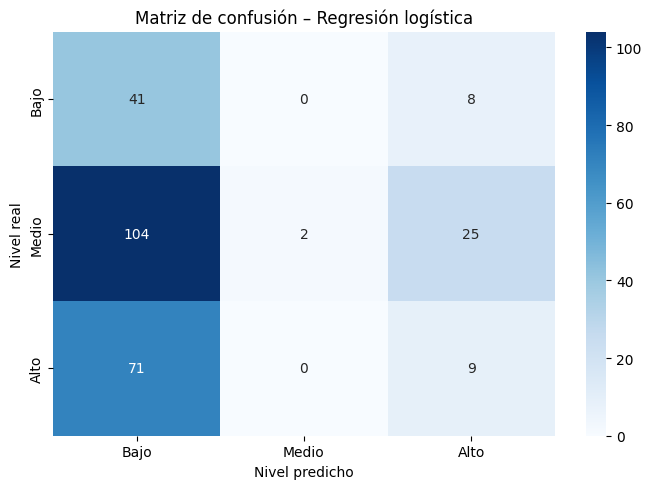

In [10]:
mejor_nombre = resultados_df.iloc[0]["Modelo"]
mejor_modelo = modelos_entrenados[mejor_nombre]
mejor_pred = predicciones[mejor_nombre]

print("Mejor modelo provisional:", mejor_nombre)

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        mejor_pred,
        labels=["Bajo", "Medio", "Alto"],
        zero_division=0
    )
)

matriz = confusion_matrix(
    y_test,
    mejor_pred,
    labels=["Bajo", "Medio", "Alto"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bajo", "Medio", "Alto"],
    yticklabels=["Bajo", "Medio", "Alto"]
)

plt.title(
    f"Matriz de confusión – {mejor_nombre}"
)
plt.xlabel("Nivel predicho")
plt.ylabel("Nivel real")
plt.tight_layout()
plt.show()